# Improved GAM Analysis: Predicting Secchi Depth from PAR Variables

This notebook follows best practices for GAM modeling:
1. Exploratory Data Analysis (EDA)
2. Initial flexible GAM to assess functional forms
3. Model simplification based on EDF
4. Model comparison and selection
5. Final model diagnostics and validation

## 1. Load and Prepare Data

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pygam import LinearGAM, s, l, f, GAM
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from scipy import stats


In [12]:
# Load data
df = pd.read_parquet("../data/Parquet/Enhanced.parquet")

print(f"Dataset shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")

Dataset shape: (2388, 40)

Columns: ['ORD_OCC', 'CAST_ID', 'DATE_TIME_UTC', 'DATE_TIME_PST', 'LAT_DEC', 'LON_DEC', 'STA_ID', 'LINE', 'STA', 'DEPTH', 'PRESSURE', 'ESTCHL_CRUISECORR', 'ESTCHL_STACORR', 'BAT', 'XMISS', 'SPAR', 'PAR', 'CHL_A', 'PHAEO', 'CAST_COUNT', 'Cruise_ID', 'Cruz_Sta', 'Distance', 'Date', 'Time', 'Lat_Dec', 'Lon_Dec', 'Ac_Line', 'Bottom_D', 'Secchi', 'IntChl', 'IntC14', 'TimeZone', 'Visibility', 'PHOTIC_ZONE', 'baseline_depth', 'XMISS_SUMMED', 'CHL_A_SUMMED', 'PHAEO_SUMMED', 'K_PAR']


In [48]:
# Identify PAR-related variables (capitalized)
variables = ['ESTCHL_STACORR', 'BAT', 'XMISS_SUMMED', 'SPAR', 'PAR', 'CHL_A_SUMMED', 'PHAEO_SUMMED', 'K_PAR']
target = 'Secchi'

# Create clean dataset
df_clean = df[variables + [target]].dropna()

print(f"Clean dataset shape: {df_clean.shape}")
print(f"Missing values removed: {df.shape[0] - df_clean.shape[0]}")
print(f"\nVariables for modeling:")
print(f"  Predictors: {variables}")
print(f"  Target: {target}")

Clean dataset shape: (2148, 9)
Missing values removed: 240

Variables for modeling:
  Predictors: ['ESTCHL_STACORR', 'BAT', 'XMISS_SUMMED', 'SPAR', 'PAR', 'CHL_A_SUMMED', 'PHAEO_SUMMED', 'K_PAR']
  Target: Secchi


In [14]:
# Basic statistics
print("Descriptive Statistics:")
print(df_clean.describe())

Descriptive Statistics:
       ESTCHL_STACORR          BAT  XMISS_SUMMED          SPAR           PAR  \
count     2148.000000  2148.000000   2148.000000  2.148000e+03  2.148000e+03   
mean         1.269752     5.271991   2622.340070 -9.021139e+15  8.176509e+01   
std          2.580716    16.194145   2022.836862  3.346592e+16  1.593809e+02   
min          0.000000   -99.000000  -6633.000000 -2.251000e+17  1.000000e-12   
25%          0.290000     0.610000   1076.855000  0.000000e+00  3.337500e+00   
50%          0.560000     0.717400   2387.105000  4.921500e+01  1.434500e+01   
75%          1.060000     1.070000   3850.205000  1.387175e+03  4.780500e+01   
max         39.705300    69.070000  12683.020000  1.200000e+05  1.490300e+03   

       CHL_A_SUMMED  PHAEO_SUMMED        K_PAR       Secchi  
count   2148.000000   2148.000000  2148.000000  2148.000000  
mean       3.710358      1.512431     0.133145    19.006052  
std        6.442191     26.495623     0.391977     8.560503  
min    

## 2. Exploratory Data Analysis

Visualize relationships to understand which variables need non-linear terms

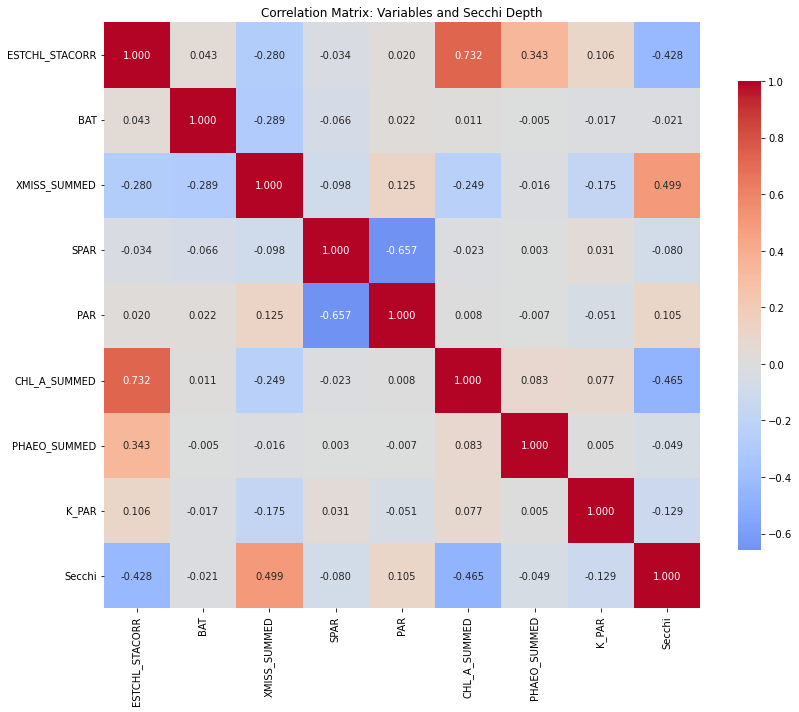


Correlations with Secchi depth:
Secchi            1.000000
XMISS_SUMMED      0.498716
PAR               0.104879
BAT              -0.020820
PHAEO_SUMMED     -0.048933
SPAR             -0.080396
K_PAR            -0.128513
ESTCHL_STACORR   -0.427700
CHL_A_SUMMED     -0.464843
Name: Secchi, dtype: float64


In [15]:
# Correlation matrix
plt.figure(figsize=(12, 10))
sns.heatmap(df_clean.corr(), annot=True, fmt='.3f', cmap='coolwarm', center=0, cbar_kws={'shrink': 0.8})
plt.title('Correlation Matrix: Variables and Secchi Depth')
plt.tight_layout()
plt.show()

print("\nCorrelations with Secchi depth:")
print(df_clean.corr()[target].sort_values(ascending=False))

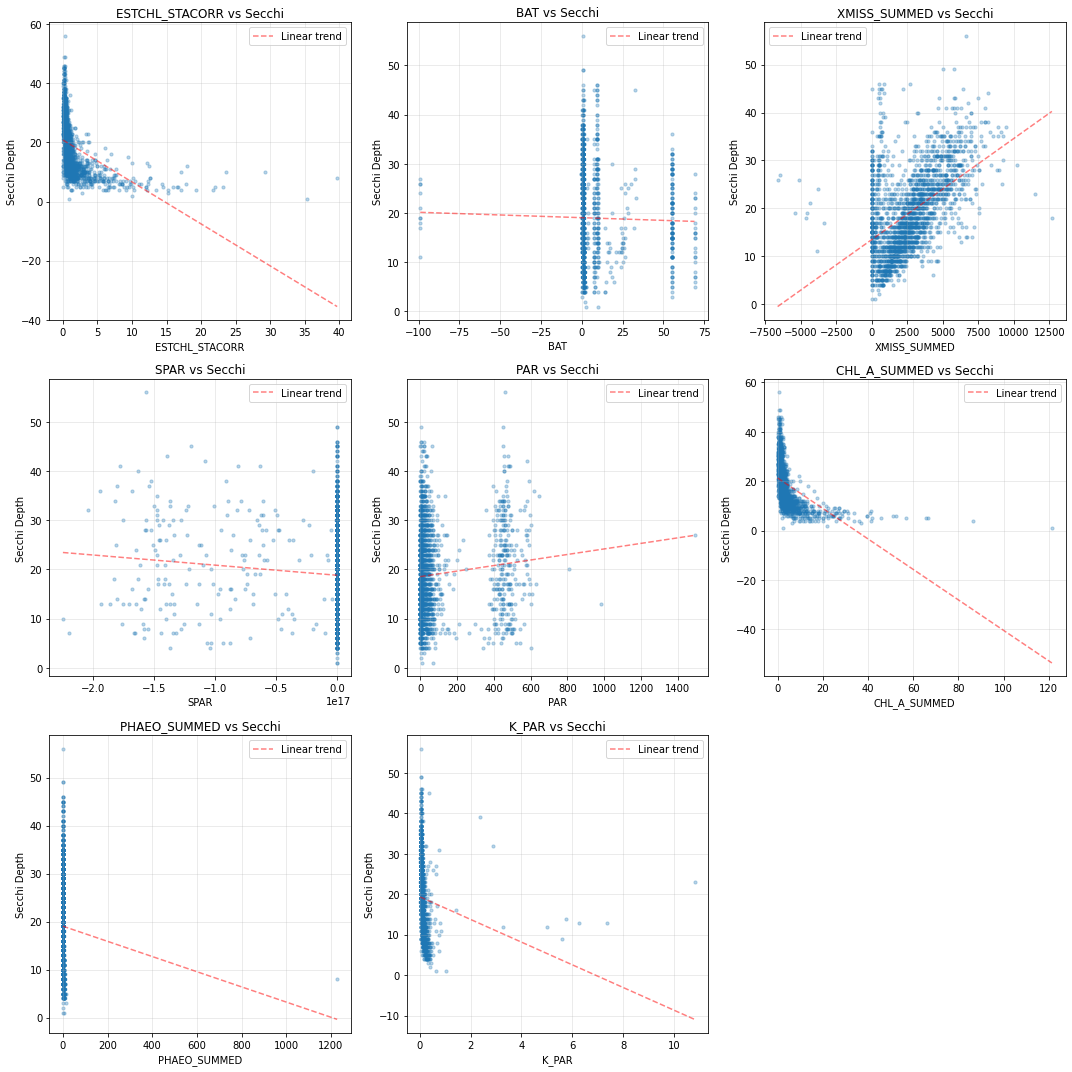

In [17]:
# Scatter plots for each predictor vs Secchi
n_vars = len(variables)
n_cols = 3
n_rows = (n_vars + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
axes = axes.flatten()

for i, var in enumerate(variables):
    axes[i].scatter(df_clean[var], df_clean[target], alpha=0.3, s=10)
    axes[i].set_xlabel(var)
    axes[i].set_ylabel('Secchi Depth')
    axes[i].set_title(f'{var} vs Secchi')
    
    # Add trend line
    z = np.polyfit(df_clean[var], df_clean[target], 1)
    p = np.poly1d(z)
    x_line = np.linspace(df_clean[var].min(), df_clean[var].max(), 100)
    axes[i].plot(x_line, p(x_line), 'r--', alpha=0.5, label='Linear trend')
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)

# Remove extra subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


Linear relationships -> Consider linear terms l()
Curved patterns -> Need smooth terms s()
No clear pattern -> Variable may not be useful

## 3. Prepare Train/Test Split

In [18]:
# Prepare X and y
X = df_clean[variables].values
y = df_clean[target].values

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")

Training set: 1718 samples
Test set: 430 samples


## 4. Fit Initial Flexible GAM

Start with all smooth terms to assess which variables need non-linear functions

In [19]:
# Fit GAM with all smooth terms
gam_flexible = LinearGAM(
    s(0) + s(1) + s(2) + s(3) + s(4) + s(5) + s(6) + s(7)
).fit(X_train, y_train)

# Get predictions
y_pred_train = gam_flexible.predict(X_train)
y_pred_test = gam_flexible.predict(X_test)

# Performance metrics
train_r2 = r2_score(y_train, y_pred_train)
test_r2 = r2_score(y_test, y_pred_test)
train_rmse = np.sqrt(mean_squared_error(y_train, y_pred_train))
test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))

print("="*70)
print("FLEXIBLE GAM (ALL SMOOTH TERMS)")
print("="*70)
print(f"\nTraining Set:")
print(f"  R²: {train_r2:.4f}")
print(f"  RMSE: {train_rmse:.4f}")
print(f"\nTest Set:")
print(f"  R²: {test_r2:.4f}")
print(f"  RMSE: {test_rmse:.4f}")
print(f"\nModel Statistics:")
print(f"  AIC: {gam_flexible.statistics_['AIC']:.2f}")
print(f"  GCV: {gam_flexible.statistics_['GCV']:.4f}")

FLEXIBLE GAM (ALL SMOOTH TERMS)

Training Set:
  R²: 0.7040
  RMSE: 4.6098

Test Set:
  R²: 0.7011
  RMSE: 4.8605

Model Statistics:
  AIC: 13959.89
  GCV: 23.3032


In [23]:
print("\n" + "="*70)
print("EFFECTIVE DEGREES OF FREEDOM (EDF) ANALYSIS")
print("="*70)
print("(EDF ≈ 1 suggests linear relationship)\n")

# Get EDF per coefficient
edof_per_coef = gam_flexible.statistics_['edof_per_coef']

# Calculate EDF for each term by summing over its basis functions
edfs = []
current_idx = 0

for i, term in enumerate(gam_flexible.terms):
    if term.isintercept:
        current_idx += 1  # Skip intercept
        continue
    
    # Number of coefficients for this term
    n_coefs = term.n_coefs
    
    # Sum the EDFs for this term's coefficients
    term_edf = edof_per_coef[current_idx:current_idx + n_coefs].sum()
    edfs.append(term_edf)
    
    current_idx += n_coefs

edfs = np.array(edfs)

print(f"Total EDF (excluding intercept): {edfs.sum():.2f}")
print(f"Model total EDF: {gam_flexible.statistics_['edof']:.2f}")
print(f"\nIndividual term EDFs:\n")

for i, var in enumerate(variables):
    edf = edfs[i]
    if edf < 1.5:
        interpretation = "LINEAR"
        recommendation = "Use l()"
    elif edf < 3:
        interpretation = "MILDLY NON-LINEAR"
        recommendation = "Keep s()"
    else:
        interpretation = "STRONGLY NON-LINEAR"
        recommendation = "Keep s()"
    
    print(f"  {var:20s}: EDF = {edf:5.2f}  [{interpretation:20s}] → {recommendation}")

print("\nRecommendation:")
print("  EDF < 1.5  → Use linear term l()")
print("  EDF ≥ 1.5  → Keep smooth term s()")

if edfs.sum() > 30:
    print("\n⚠️  WARNING: Total EDF is very high (>30)!")
    print("    This suggests potential overfitting.")
    print("    Grid search for optimal smoothing is CRITICAL.")


EFFECTIVE DEGREES OF FREEDOM (EDF) ANALYSIS
(EDF ≈ 1 suggests linear relationship)

Total EDF (excluding intercept): 55.31
Model total EDF: 55.31

Individual term EDFs:

  ESTCHL_STACORR      : EDF = 10.56  [STRONGLY NON-LINEAR ] → Keep s()
  BAT                 : EDF =  5.85  [STRONGLY NON-LINEAR ] → Keep s()
  XMISS_SUMMED        : EDF =  9.48  [STRONGLY NON-LINEAR ] → Keep s()
  SPAR                : EDF =  9.43  [STRONGLY NON-LINEAR ] → Keep s()
  PAR                 : EDF =  6.92  [STRONGLY NON-LINEAR ] → Keep s()
  CHL_A_SUMMED        : EDF =  7.10  [STRONGLY NON-LINEAR ] → Keep s()
  PHAEO_SUMMED        : EDF =  0.40  [LINEAR              ] → Use l()
  K_PAR               : EDF =  5.56  [STRONGLY NON-LINEAR ] → Keep s()

Recommendation:
  EDF < 1.5  → Use linear term l()
  EDF ≥ 1.5  → Keep smooth term s()

⚠️  WARNING: Total EDF is very high (>30)!
    This suggests potential overfitting.
    Grid search for optimal smoothing is CRITICAL.


## 6. Grid Search for Optimal Smoothing

**CRITICAL STEP:** Since EDF is high, we need to find optimal smoothing parameters to prevent overfitting

In [26]:
print("\n" + "="*70)
print("GRID SEARCH FOR OPTIMAL SMOOTHING PENALTY")
print("="*70)

# Search over lambda values to reduce overfitting
lams = np.logspace(-3, 5, 20)  # Range of lambda values

print("\nPerforming grid search for optimal lambda...")
print("This may take a minute...\n")

gam_gridsearch = LinearGAM(
    s(0) + s(1) + s(2) + s(3) + s(4) + s(5) + s(6) + s(7)
).gridsearch(X_train, y_train, lam=lams)

print(f"Optimal lambda values found:")
for i, var in enumerate(variables):
    print(f"  {var:20s}: λ = {gam_gridsearch.lam[i][0]:.4f}")

print(f"\nOptimized model EDF: {gam_gridsearch.statistics_['edof']:.2f}")
print(f"Original model EDF: {edfs.sum():.2f}")
print(f"EDF reduction: {edfs.sum() - gam_gridsearch.statistics_['edof']:.2f}")

# Update the flexible model with optimized version
gam_flexible = gam_gridsearch

# Recalculate EDFs with optimized lambda
edof_per_coef = gam_flexible.statistics_['edof_per_coef']
edfs_optimized = []
current_idx = 0

for i, term in enumerate(gam_flexible.terms):
    if term.isintercept:
        current_idx += 1
        continue
    
    n_coefs = term.n_coefs
    term_edf = edof_per_coef[current_idx:current_idx + n_coefs].sum()
    edfs_optimized.append(term_edf)
    current_idx += n_coefs

edfs = np.array(edfs_optimized)

print(f"\nOptimized Individual term EDFs:\n")
for i, var in enumerate(variables):
    edf = edfs[i]
    if edf < 1.5:
        interpretation = "LINEAR"
        recommendation = "Use l()"
    elif edf < 3:
        interpretation = "MILDLY NON-LINEAR"
        recommendation = "Keep s()"
    else:
        interpretation = "STRONGLY NON-LINEAR"
        recommendation = "Keep s()"
    
    print(f"  {var:20s}: EDF = {edf:5.2f}  [{interpretation:20s}] → {recommendation}")

# Get performance after optimization
y_pred_train_opt = gam_flexible.predict(X_train)
y_pred_test_opt = gam_flexible.predict(X_test)

print(f"\nOptimized Model Performance:")
print(f"  Training R²: {r2_score(y_train, y_pred_train_opt):.4f}")
print(f"  Test R²: {r2_score(y_test, y_pred_test_opt):.4f}")
print(f"  Training RMSE: {np.sqrt(mean_squared_error(y_train, y_pred_train_opt)):.4f}")
print(f"  Test RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_test_opt)):.4f}")

  0% (0 of 20) |                         | Elapsed Time: 0:00:00 ETA:  --:--:--



GRID SEARCH FOR OPTIMAL SMOOTHING PENALTY

Performing grid search for optimal lambda...
This may take a minute...



  5% (1 of 20) |#                        | Elapsed Time: 0:00:00 ETA:   0:00:15
 10% (2 of 20) |##                       | Elapsed Time: 0:00:01 ETA:   0:00:11
 15% (3 of 20) |###                      | Elapsed Time: 0:00:01 ETA:   0:00:10
 20% (4 of 20) |#####                    | Elapsed Time: 0:00:02 ETA:   0:00:08
 25% (5 of 20) |######                   | Elapsed Time: 0:00:02 ETA:   0:00:07
 30% (6 of 20) |#######                  | Elapsed Time: 0:00:02 ETA:   0:00:06
 35% (7 of 20) |########                 | Elapsed Time: 0:00:03 ETA:   0:00:05
 40% (8 of 20) |##########               | Elapsed Time: 0:00:03 ETA:   0:00:05
 45% (9 of 20) |###########              | Elapsed Time: 0:00:04 ETA:   0:00:05
 50% (10 of 20) |############            | Elapsed Time: 0:00:04 ETA:   0:00:04
 55% (11 of 20) |#############           | Elapsed Time: 0:00:05 ETA:   0:00:04
 60% (12 of 20) |##############          | Elapsed Time: 0:00:05 ETA:   0:00:03
 65% (13 of 20) |###############        

Optimal lambda values found:
  ESTCHL_STACORR      : λ = 0.0183
  BAT                 : λ = 0.0183
  XMISS_SUMMED        : λ = 0.0183
  SPAR                : λ = 0.0183
  PAR                 : λ = 0.0183
  CHL_A_SUMMED        : λ = 0.0183
  PHAEO_SUMMED        : λ = 0.0183
  K_PAR               : λ = 0.0183

Optimized model EDF: 82.16
Original model EDF: 55.31
EDF reduction: -26.85

Optimized Individual term EDFs:

  ESTCHL_STACORR      : EDF = 13.71  [STRONGLY NON-LINEAR ] → Keep s()
  BAT                 : EDF =  7.64  [STRONGLY NON-LINEAR ] → Keep s()
  XMISS_SUMMED        : EDF = 13.78  [STRONGLY NON-LINEAR ] → Keep s()
  SPAR                : EDF = 15.27  [STRONGLY NON-LINEAR ] → Keep s()
  PAR                 : EDF = 10.06  [STRONGLY NON-LINEAR ] → Keep s()
  CHL_A_SUMMED        : EDF = 11.67  [STRONGLY NON-LINEAR ] → Keep s()
  PHAEO_SUMMED        : EDF =  0.90  [LINEAR              ] → Use l()
  K_PAR               : EDF =  9.13  [STRONGLY NON-LINEAR ] → Keep s()

Optimized Mod

## 7. Visualize Partial Dependence Plots

Show the learned smooth functions for each variable (after optimization)

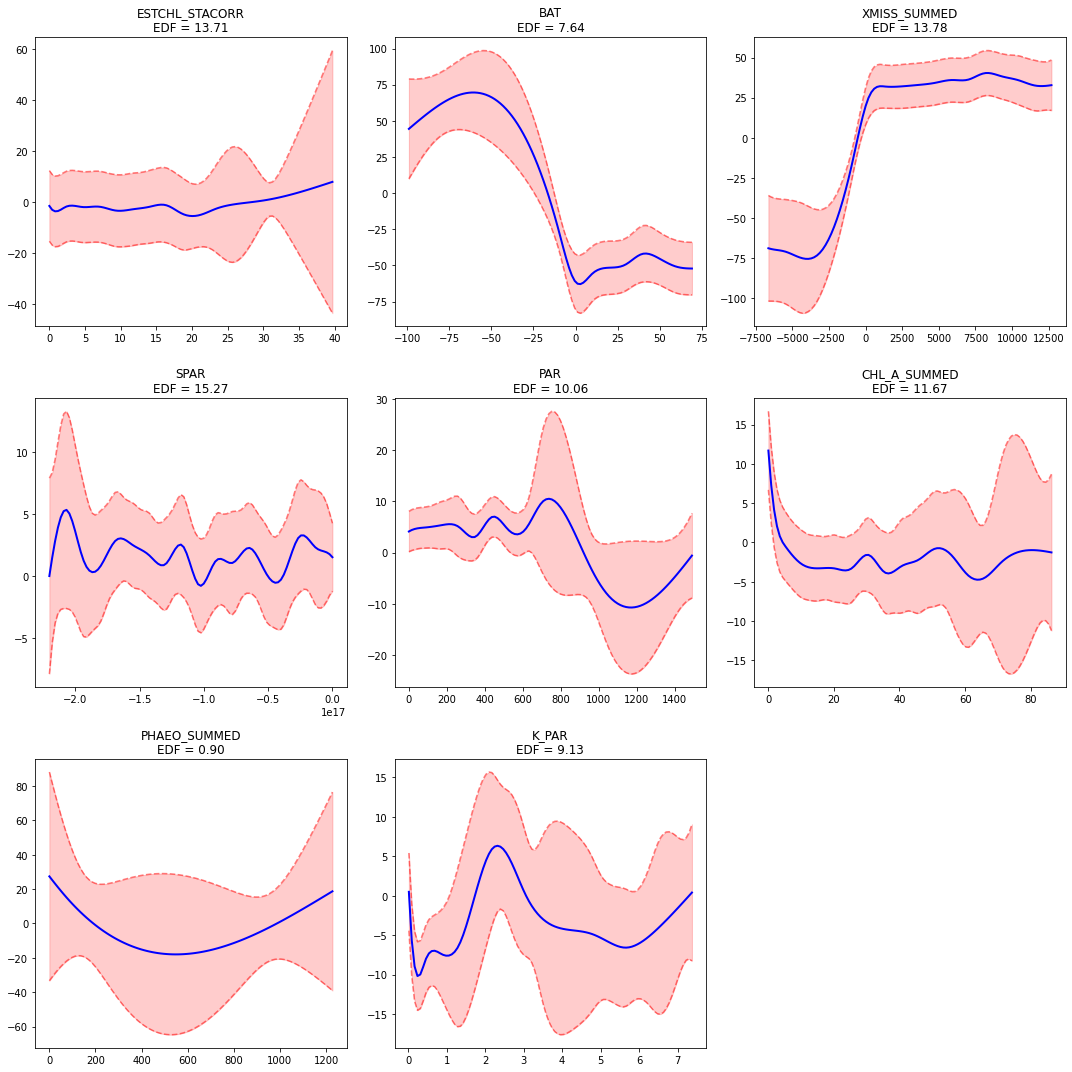

In [30]:
# Plot partial dependence for each feature
n_vars = len(variables)
n_cols = 3
n_rows = (n_vars + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
axes = axes.flatten()

for i, var in enumerate(variables):
    XX = gam_flexible.generate_X_grid(term=i)

    pdep, conf = gam_flexible.partial_dependence(
        term=i,
        X=XX,
        width=0.95
    )

    lower = conf[:, 0]
    upper = conf[:, 1]

    axes[i].plot(XX[:, i], pdep, 'b-', linewidth=2, label='Partial effect')
    axes[i].plot(XX[:, i], lower, 'r--', alpha=0.5)
    axes[i].plot(XX[:, i], upper, 'r--', alpha=0.5)
    axes[i].fill_between(XX[:, i], lower, upper, alpha=0.2, color='red')
    axes[i].set_title(f"{var}\nEDF = {edfs[i]:.2f}", fontsize=12)

# Remove extra subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

Interpretation:
Straight lines suggest linear relationships
Curves show non-linear effects
Wide confidence bands suggest high uncertainty

## 8. Build Alternative Models Based on EDF

In [32]:
print("\n" + "="*70)
print("BUILDING ALTERNATIVE MODELS")
print("="*70)

# Model 1: Optimized smooth (baseline)
model_specs = {
    'Optimized Smooth': s(0, lam=gam_flexible.lam[0]) + s(1, lam=gam_flexible.lam[1]) + 
                        s(2, lam=gam_flexible.lam[2]) + s(3, lam=gam_flexible.lam[3]) + 
                        s(4, lam=gam_flexible.lam[4]) + s(5, lam=gam_flexible.lam[5]) + 
                        s(6, lam=gam_flexible.lam[6]) + s(7, lam=gam_flexible.lam[7])
}

# Model 2: EDF Simplified (convert EDF < 1.5 to linear)
terms_simplified = []
for i, edf in enumerate(edfs):
    if edf < 1.5:
        terms_simplified.append(l(i))
    else:
        terms_simplified.append(s(i, lam=gam_flexible.lam[i]))
model_specs['EDF Simplified'] = sum(terms_simplified[1:], terms_simplified[0])

# Model 3: Conservative (convert EDF < 3 to linear)
terms_conservative = []
for i, edf in enumerate(edfs):
    if edf < 3.0:
        terms_conservative.append(l(i))
    else:
        terms_conservative.append(s(i, lam=gam_flexible.lam[i]))
model_specs['Conservative'] = sum(terms_conservative[1:], terms_conservative[0])

# Model 4: All linear (for comparison)
model_specs['All Linear'] = l(0) + l(1) + l(2) + l(3) + l(4) + l(5) + l(6) + l(7)

# Model 5: Top 5 variables (based on correlation)
correlations = df_clean[variables].corrwith(df_clean[target]).abs().sort_values(ascending=False)
print("\nTop correlated variables:")
print(correlations)

top_5_vars = correlations.head(5).index.tolist()
top_5_indices = [variables.index(var) for var in top_5_vars]
print(f"\nTop 5 variables: {top_5_vars}")

# Build formula for top 5
top_5_terms = []
for idx in range(len(variables)):
    if idx in top_5_indices:
        if edfs[idx] < 1.5:
            top_5_terms.append(l(idx))
        else:
            top_5_terms.append(s(idx, lam=gam_flexible.lam[idx]))

if len(top_5_terms) > 0:
    model_specs['Top 5 Variables'] = sum(top_5_terms[1:], top_5_terms[0])

print(f"\nCreated {len(model_specs)} model specifications:")
for name in model_specs.keys():
    print(f"  - {name}")


BUILDING ALTERNATIVE MODELS

Top correlated variables:
XMISS_SUMMED      0.498716
CHL_A_SUMMED      0.464843
ESTCHL_STACORR    0.427700
K_PAR             0.128513
PAR               0.104879
SPAR              0.080396
PHAEO_SUMMED      0.048933
BAT               0.020820
dtype: float64

Top 5 variables: ['XMISS_SUMMED', 'CHL_A_SUMMED', 'ESTCHL_STACORR', 'K_PAR', 'PAR']

Created 5 model specifications:
  - Optimized Smooth
  - EDF Simplified
  - Conservative
  - All Linear
  - Top 5 Variables


Created 5 models:
Optimized Smooth: Fully flexible baseline (most complex)
EDF Simplified: Remove splines where EDF ≈ linear
Conservative: Only allow strong nonlinearities
All Linear: Pure linear regression baseline
Top 5 Variables: Dimensionality reduction

## 9. Compare Models with Cross-Validation

In [33]:
def cross_validate_gam(X, y, formula, n_folds=5):
    """Cross-validate a GAM model"""
    kf = KFold(n_splits=n_folds, shuffle=True, random_state=42)
    
    rmse_scores = []
    r2_scores = []
    mae_scores = []
    
    for train_idx, val_idx in kf.split(X):
        X_train_fold, X_val_fold = X[train_idx], X[val_idx]
        y_train_fold, y_val_fold = y[train_idx], y[val_idx]
        
        try:
            # Fit model
            gam = GAM(formula).fit(X_train_fold, y_train_fold)
            
            # Predict
            y_pred = gam.predict(X_val_fold)
            
            # Calculate metrics
            rmse_scores.append(np.sqrt(mean_squared_error(y_val_fold, y_pred)))
            r2_scores.append(r2_score(y_val_fold, y_pred))
            mae_scores.append(mean_absolute_error(y_val_fold, y_pred))
        except Exception as e:
            print(f"  Warning: Fold failed with error: {e}")
            continue
    
    if len(rmse_scores) == 0:
        return {
            'RMSE': (np.nan, np.nan),
            'R2': (np.nan, np.nan),
            'MAE': (np.nan, np.nan)
        }
    
    return {
        'RMSE': (np.mean(rmse_scores), np.std(rmse_scores)),
        'R2': (np.mean(r2_scores), np.std(r2_scores)),
        'MAE': (np.mean(mae_scores), np.std(mae_scores))
    }

# Compare all models
print("\n" + "="*70)
print("CROSS-VALIDATION RESULTS (5-FOLD)")
print("="*70)
print(f"\n{'Model':<25} {'RMSE':<20} {'R²':<20} {'MAE':<20}")
print("="*85)

cv_results = {}
for name, formula in model_specs.items():
    print(f"Validating {name}...", end=" ")
    results = cross_validate_gam(X_train, y_train, formula)
    cv_results[name] = results
    
    rmse_mean, rmse_std = results['RMSE']
    r2_mean, r2_std = results['R2']
    mae_mean, mae_std = results['MAE']
    
    if not np.isnan(rmse_mean):
        print(f"\n{name:<25} {rmse_mean:6.3f} ± {rmse_std:5.3f}    "
              f"{r2_mean:6.3f} ± {r2_std:5.3f}    "
              f"{mae_mean:6.3f} ± {mae_std:5.3f}")
    else:
        print(f"\n{name:<25} FAILED")

print("\n" + "="*70)
print("BEST MODEL SELECTION CRITERIA:")
print("="*70)
print("  - Highest R² (with reasonable RMSE)")
print("  - Lower standard deviation suggests more stable model")
print("  - Prefer simpler models if performance is similar")

# Find best model based on R2
valid_results = {k: v for k, v in cv_results.items() if not np.isnan(v['R2'][0])}
if len(valid_results) > 0:
    best_model_name = max(valid_results.items(), key=lambda x: x[1]['R2'][0])[0]
    print(f"\nBest model by R²: {best_model_name}")
    print(f"  R² = {cv_results[best_model_name]['R2'][0]:.4f} ± {cv_results[best_model_name]['R2'][1]:.4f}")
    print(f"  RMSE = {cv_results[best_model_name]['RMSE'][0]:.4f} ± {cv_results[best_model_name]['RMSE'][1]:.4f}")
else:
    best_model_name = 'Optimized Smooth'
    print(f"\nDefaulting to: {best_model_name}")


CROSS-VALIDATION RESULTS (5-FOLD)

Model                     RMSE                 R²                   MAE                 
Validating Optimized Smooth... 
Optimized Smooth           6.679 ± 3.382     0.185 ± 0.943     3.749 ± 0.258
Validating EDF Simplified... 
EDF Simplified             6.725 ± 3.268     0.188 ± 0.906     3.760 ± 0.245
Validating Conservative... 
Conservative               6.725 ± 3.268     0.188 ± 0.906     3.760 ± 0.245
Validating All Linear... 
All Linear                32.221 ± 51.030    -53.652 ± 108.069     6.606 ± 2.726
Validating Top 5 Variables... 
Top 5 Variables            5.008 ± 0.481     0.648 ± 0.063     3.619 ± 0.131

BEST MODEL SELECTION CRITERIA:
  - Highest R² (with reasonable RMSE)
  - Lower standard deviation suggests more stable model
  - Prefer simpler models if performance is similar

Best model by R²: Top 5 Variables
  R² = 0.6478 ± 0.0634
  RMSE = 5.0075 ± 0.4808


## 10. Select and Refit Final Model

Choose the best model and fit on full training data

In [35]:
# SELECT YOUR BEST MODEL HERE based on CV results
# For now, using 'All Smooth' as default
best_model_name = 'Top 5 Variables'  # CHANGE THIS based on your results
best_formula = model_specs[best_model_name]

print(f"Selected model: {best_model_name}\n")

# Fit final model on full training data
final_gam = GAM(best_formula).fit(X_train, y_train)

# Get predictions
y_pred_train_final = final_gam.predict(X_train)
y_pred_test_final = final_gam.predict(X_test)

# Performance on train and test
print("Final Model Performance:")
print(f"\nTraining Set:")
print(f"  R²: {r2_score(y_train, y_pred_train_final):.4f}")
print(f"  RMSE: {np.sqrt(mean_squared_error(y_train, y_pred_train_final)):.4f}")
print(f"  MAE: {mean_absolute_error(y_train, y_pred_train_final):.4f}")

print(f"\nTest Set:")
print(f"  R²: {r2_score(y_test, y_pred_test_final):.4f}")
print(f"  RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_test_final)):.4f}")
print(f"  MAE: {mean_absolute_error(y_test, y_pred_test_final):.4f}")

print(f"\nModel Statistics:")
print(f"  AIC: {final_gam.statistics_['AIC']:.2f}")
print(f"  GCV: {final_gam.statistics_['GCV']:.4f}")

print("\nFull Model Summary:")
print(final_gam.summary())

Selected model: Top 5 Variables

Final Model Performance:

Training Set:
  R²: 0.7161
  RMSE: 4.5146
  MAE: 3.4111

Test Set:
  R²: 0.7225
  RMSE: 4.6827
  MAE: 3.4645

Model Statistics:
  AIC: 13839.36
  GCV: 22.5402

Full Model Summary:
GAM                                                                                                       
=============================================== ==========================================================
Distribution:                        NormalDist Effective DoF:                                     60.2303
Link Function:                     IdentityLink Log Likelihood:                                 -6858.4496
Number of Samples:                         1718 AIC:                                            13839.3598
                                                AICc:                                           13843.9623
                                                GCV:                                               22.5402
            

/var/folders/h5/5xrw7jkn4ds1x0mfqzpx8vp00000gn/T/ipykernel_61046/1419359242.py:32: UserWarning: KNOWN BUG: p-values computed in this summary are likely much smaller than they should be. 
 
Please do not make inferences based on these values! 

Collaborate on a solution, and stay up to date at: 
github.com/dswah/pyGAM/issues/163 

  print(final_gam.summary())


## 11. Model Diagnostics

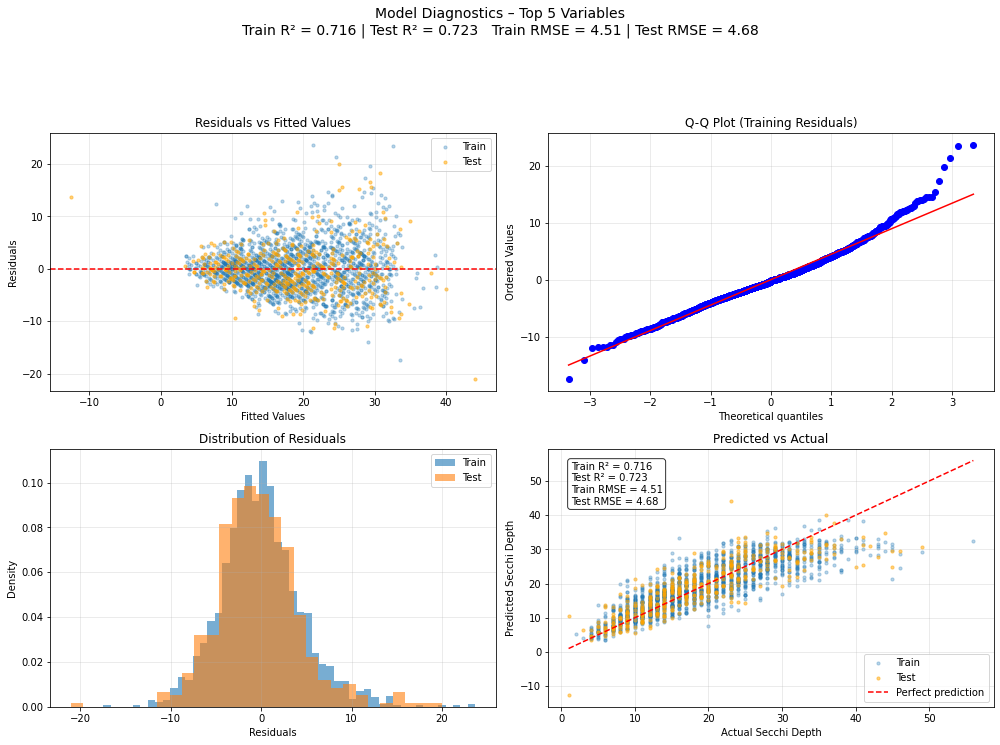


Diagnostic Interpretation:
  1. Residuals vs Fitted: Should show random scatter around 0 (no patterns)
  2. Q-Q Plot: Points should follow the diagonal line (normal residuals)
  3. Histogram: Should be approximately normal (bell-shaped)
  4. Predicted vs Actual: Points should cluster around the diagonal line


In [40]:
train_r2 = r2_score(y_train, y_pred_train_final)
test_r2 = r2_score(y_test, y_pred_test_final)

train_rmse = np.sqrt(mean_squared_error(y_train, y_pred_train_final))
test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test_final))

# Calculate residuals
residuals_train = y_train - y_pred_train_final
residuals_test = y_test - y_pred_test_final

# Diagnostic plots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Residuals vs Fitted
axes[0, 0].scatter(y_pred_train_final, residuals_train, alpha=0.3, s=10, label='Train')
axes[0, 0].scatter(y_pred_test_final, residuals_test, alpha=0.5, s=10, label='Test', color='orange')
axes[0, 0].axhline(0, color='red', linestyle='--')
axes[0, 0].set_xlabel('Fitted Values')
axes[0, 0].set_ylabel('Residuals')
axes[0, 0].set_title('Residuals vs Fitted Values')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2. Q-Q Plot (normality of residuals)
stats.probplot(residuals_train, dist="norm", plot=axes[0, 1])
axes[0, 1].set_title('Q-Q Plot (Training Residuals)')
axes[0, 1].grid(True, alpha=0.3)

# 3. Histogram of residuals
axes[1, 0].hist(residuals_train, bins=50, alpha=0.6, label='Train', density=True)
axes[1, 0].hist(residuals_test, bins=30, alpha=0.6, label='Test', density=True)
axes[1, 0].set_xlabel('Residuals')
axes[1, 0].set_ylabel('Density')
axes[1, 0].set_title('Distribution of Residuals')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# 4. Predicted vs Actual
axes[1, 1].scatter(y_train, y_pred_train_final, alpha=0.3, s=10, label='Train')
axes[1, 1].scatter(y_test, y_pred_test_final, alpha=0.5, s=10, label='Test', color='orange')
min_val = min(y_train.min(), y_test.min())
max_val = max(y_train.max(), y_test.max())
axes[1, 1].plot([min_val, max_val], [min_val, max_val], 'r--', label='Perfect prediction')
axes[1, 1].set_xlabel('Actual Secchi Depth')
axes[1, 1].set_ylabel('Predicted Secchi Depth')
axes[1, 1].set_title('Predicted vs Actual')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].text(
    0.05, 0.95,
    f"Train R² = {train_r2:.3f}\n"
    f"Test R² = {test_r2:.3f}\n"
    f"Train RMSE = {train_rmse:.2f}\n"
    f"Test RMSE = {test_rmse:.2f}",
    transform=axes[1, 1].transAxes,
    fontsize=10,
    verticalalignment='top',
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
)

# Add overall model title + metrics
fig.suptitle(
    f"Model Diagnostics – {best_model_name}\n"
    f"Train R² = {train_r2:.3f} | Test R² = {test_r2:.3f}   "
    f"Train RMSE = {train_rmse:.2f} | Test RMSE = {test_rmse:.2f}",
    fontsize=14,
    y=1.03
)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


print("\nDiagnostic Interpretation:")
print("  1. Residuals vs Fitted: Should show random scatter around 0 (no patterns)")
print("  2. Q-Q Plot: Points should follow the diagonal line (normal residuals)")
print("  3. Histogram: Should be approximately normal (bell-shaped)")
print("  4. Predicted vs Actual: Points should cluster around the diagonal line")

## 12. Feature Importance Analysis


FEATURE IMPORTANCE ANALYSIS

Ranked by Range of Partial Effect:
      Variable  Importance       EDF  Correlation  Normalized Importance
ESTCHL_STACORR   24.443561 10.221736    -0.427700               0.301019
           PAR   19.881737  9.176005     0.104879               0.244841
         K_PAR   19.041122 11.918339    -0.128513               0.234489
  CHL_A_SUMMED   11.067519 15.395970    -0.464843               0.136295
  XMISS_SUMMED    6.768833 13.518247     0.498716               0.083357


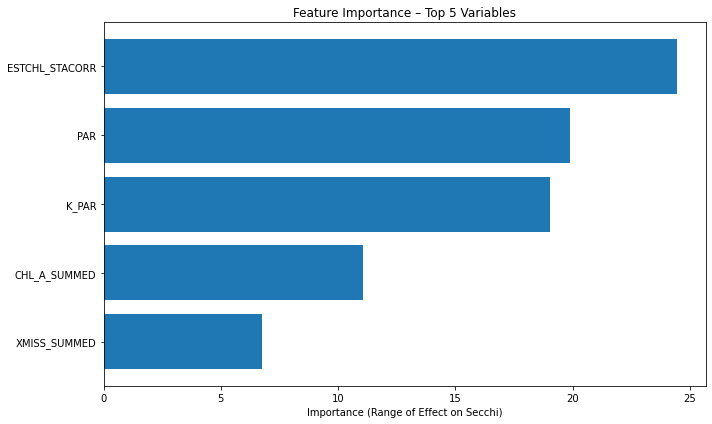

In [45]:
# Feature Importance (FINAL GAM)

importance_scores = []
model_vars = []

# Loop through actual GAM terms (skip intercept)
for i, term in enumerate(final_gam.terms):
    
    if term.isintercept:
        continue
    
    # Generate grid for this term
    XX = final_gam.generate_X_grid(term=i)
    pdep = final_gam.partial_dependence(term=i, X=XX)
    
    # Range of partial effect = importance
    importance = pdep.max() - pdep.min()
    importance_scores.append(importance)
    
    # Track correct variable name
    if best_model_name == 'Top 5 Variables':
        model_vars.append(top_5_vars[len(model_vars)])
    else:
        model_vars.append(variables[len(model_vars)])


# Get final EDFs

edof_per_coef_final = final_gam.statistics_['edof_per_coef']
edfs_final = []
current_idx = 0

for term in final_gam.terms:
    if term.isintercept:
        current_idx += 1
        continue
    
    n_coefs = term.n_coefs
    term_edf = edof_per_coef_final[current_idx:current_idx + n_coefs].sum()
    edfs_final.append(term_edf)
    current_idx += n_coefs


# Build importance table

importance_df = pd.DataFrame({
    'Variable': model_vars,
    'Importance': importance_scores,
    'EDF': edfs_final,
    'Correlation': [df_clean[var].corr(df_clean[target]) for var in model_vars]
}).sort_values('Importance', ascending=False)

# Normalize importance (optional but recommended)
importance_df['Normalized Importance'] = (
    importance_df['Importance'] / importance_df['Importance'].sum()
)

print("\n" + "="*70)
print("FEATURE IMPORTANCE ANALYSIS")
print("="*70)
print("\nRanked by Range of Partial Effect:")
print(importance_df.to_string(index=False))

# Plot feature importance

plt.figure(figsize=(10, 6))
plt.barh(importance_df['Variable'], importance_df['Importance'])
plt.xlabel('Importance (Range of Effect on Secchi)')
plt.title(f'Feature Importance – {best_model_name}')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## 13. Summary and Recommendations

In [47]:
print("\n" + "="*70)
print("FINAL MODEL SUMMARY")
print("="*70)
print(f"\nBest Model: {best_model_name}")
print(f"\nTest Set Performance:")
print(f"  R² = {r2_score(y_test, y_pred_test_final):.4f}")
print(f"  RMSE = {np.sqrt(mean_squared_error(y_test, y_pred_test_final)):.4f}")
print(f"  MAE = {mean_absolute_error(y_test, y_pred_test_final):.4f}")

print(f"\nTop 3 Most Important Variables:")
for idx, row in importance_df.head(3).iterrows():
    print(f"  {row['Variable']}: Importance = {row['Importance']:.3f}, EDF = {row['EDF']:.2f}, Corr = {row['Correlation']:.3f}")

print("\n" + "="*70)
print("KEY FINDINGS:")
print("="*70)

# Identify linear vs non-linear features
linear_features = [variables[i] for i, edf in enumerate(edfs_final) if edf < 1.5]
nonlinear_features = [variables[i] for i, edf in enumerate(edfs_final) if edf >= 1.5]

print(f"\nLinear relationships (EDF < 1.5):")
if len(linear_features) > 0:
    for var in linear_features:
        print(f"  - {var}")
else:
    print("  - None")

print(f"\nNon-linear relationships (EDF ≥ 1.5):")
for var in nonlinear_features:
    print(f"  - {var}")

# Check for overfitting
train_r2_final = r2_score(y_train, y_pred_train_final)
test_r2_final = r2_score(y_test, y_pred_test_final)
r2_diff = train_r2_final - test_r2_final

print(f"\nOverfitting Check:")
print(f"  Train R²: {train_r2_final:.4f}")
print(f"  Test R²:  {test_r2_final:.4f}")
print(f"  Difference: {r2_diff:.4f}")
if r2_diff < 0.05:
    print("  ✓ Good generalization (minimal overfitting)")
elif r2_diff < 0.10:
    print("  ⚠ Moderate overfitting (acceptable)")
else:
    print("  ✗ High overfitting (consider simplification)")

print(f"\nModel Complexity:")
print(f"  Total EDF: {final_gam.statistics_['edof']:.2f}")
print(f"  Number of predictors: {len(variables)}")
print(f"  Average EDF per predictor: {final_gam.statistics_['edof'] / len(variables):.2f}")

print("\n" + "="*70)
print("RECOMMENDATIONS:")
print("="*70)
print("\n1. Model Interpretation:")
print("   - Review partial dependence plots for scientific validity")
print("   - Compare learned relationships with oceanographic principles")
print("   - Validate that K_PAR has strong negative effect on Secchi depth")

print("\n2. Model Improvement Options:")
if r2_diff > 0.10:
    print("   - Consider using more conservative model (fewer smooth terms)")
    print("   - Further increase smoothing penalty")

if final_gam.statistics_['edof'] > 30:
    print("   - Model complexity is still high (EDF > 30)")
    print("   - Consider feature selection or interaction terms instead")

print("   - Try 2D interaction terms for related variables")
print("   - Add spatial/temporal effects if available")

print("\n3. Physical Validation:")
print("   - K_PAR should have strong negative effect (higher attenuation = lower Secchi)")
print("   - Chlorophyll variables should reduce clarity")
print("   - XMISS (transmissivity) should increase clarity")
print("   - Compare with Beer-Lambert law expectations")

print("\n4. Next Steps:")
print("   - Validate on independent dataset")
print("   - Compare with other modeling approaches (RF, XGBoost)")
print("   - Investigate residual patterns for systematic errors")
print("   - Consider ensemble methods")




FINAL MODEL SUMMARY

Best Model: Top 5 Variables

Test Set Performance:
  R² = 0.7225
  RMSE = 4.6827
  MAE = 3.4645

Top 3 Most Important Variables:
  ESTCHL_STACORR: Importance = 24.444, EDF = 10.22, Corr = -0.428
  PAR: Importance = 19.882, EDF = 9.18, Corr = 0.105
  K_PAR: Importance = 19.041, EDF = 11.92, Corr = -0.129

KEY FINDINGS:

Linear relationships (EDF < 1.5):
  - None

Non-linear relationships (EDF ≥ 1.5):
  - ESTCHL_STACORR
  - BAT
  - XMISS_SUMMED
  - SPAR
  - PAR

Overfitting Check:
  Train R²: 0.7161
  Test R²:  0.7225
  Difference: -0.0065
  ✓ Good generalization (minimal overfitting)

Model Complexity:
  Total EDF: 60.23
  Number of predictors: 8
  Average EDF per predictor: 7.53

RECOMMENDATIONS:

1. Model Interpretation:
   - Review partial dependence plots for scientific validity
   - Compare learned relationships with oceanographic principles
   - Validate that K_PAR has strong negative effect on Secchi depth

2. Model Improvement Options:
   - Model complexity